In [38]:
# =========================
# SECTION 2: IMPORTS + CONFIG
# =========================

import pandas as pd
import numpy as np
from datetime import datetime
import yfinance as yf

# Data settings
DATA_PERIOD = "10y"
DATA_INTERVAL = "1d"

# Indicator settings
MOMENTUM_WINDOW = 20
VOLUME_WINDOW = 20
VOLATILITY_WINDOW = 20
SHORT_SMA_WINDOW = 20
LONG_SMA_WINDOW = 50

# Strategy thresholds
MIN_MOMENTUM_20D = 0.05       # +5% over 20 trading days
MIN_VOLUME_RATIO = 1.00       # today's volume >= 20-day average volume
MAX_VOLATILITY_20D = 0.03     # daily return standard deviation below 3%

# Risk/liquidity settings
MIN_AVG_DOLLAR_VOLUME = 10_000_000  # $10 million average daily dollar volume

# Disaster kill switch setting
DISASTER_DRAWDOWN_LIMIT = 0.45       # 45% daily equity drop

print("Config loaded.")

Config loaded.


In [39]:
# %%
# =========================
# SECTION 1: 2015-STYLE BASE STOCK UNIVERSE
# =========================

"""
Base universe:
This universe is intended to represent large, liquid, well-known US stocks
that an investor could reasonably have considered around 2015.

This helps reduce the hindsight bias from only choosing today's winners.
"""

STOCK_UNIVERSE = {
    # Technology / old large-cap tech
    "AAPL": "Technology",
    "MSFT": "Technology",
    "IBM": "Technology",
    "INTC": "Technology",
    "CSCO": "Technology",
    "ORCL": "Technology",
    "QCOM": "Technology",
    "TXN": "Technology",
    "HPQ": "Technology",

    # Internet / growth names already known by 2015
    "GOOGL": "Communication Services",
    "META": "Communication Services",
    "NFLX": "Communication Services",
    "AMZN": "Consumer Discretionary",
    "EBAY": "Consumer Discretionary",
    "BKNG": "Consumer Discretionary",

    # Consumer discretionary
    "HD": "Consumer Discretionary",
    "MCD": "Consumer Discretionary",
    "NKE": "Consumer Discretionary",
    "SBUX": "Consumer Discretionary",
    "LOW": "Consumer Discretionary",
    "DIS": "Communication Services",

    # Consumer staples
    "WMT": "Consumer Staples",
    "COST": "Consumer Staples",
    "PG": "Consumer Staples",
    "KO": "Consumer Staples",
    "PEP": "Consumer Staples",
    "PM": "Consumer Staples",
    "MO": "Consumer Staples",
    "CL": "Consumer Staples",

    # Financials
    "JPM": "Financials",
    "BAC": "Financials",
    "WFC": "Financials",
    "GS": "Financials",
    "MS": "Financials",
    "V": "Financials",
    "MA": "Financials",
    "AXP": "Financials",
    "BLK": "Financials",
    "C": "Financials",

    # Healthcare
    "JNJ": "Healthcare",
    "PFE": "Healthcare",
    "MRK": "Healthcare",
    "UNH": "Healthcare",
    "ABBV": "Healthcare",
    "AMGN": "Healthcare",
    "GILD": "Healthcare",
    "BMY": "Healthcare",
    "TMO": "Healthcare",
    "ABT": "Healthcare",

    # Energy
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",
    "SLB": "Energy",
    "HAL": "Energy",

    # Industrials
    "GE": "Industrials",
    "BA": "Industrials",
    "CAT": "Industrials",
    "HON": "Industrials",
    "UPS": "Industrials",
    "MMM": "Industrials",
    "LMT": "Industrials",
    "RTX": "Industrials",

    # Materials
    "LIN": "Materials",
    "APD": "Materials",
    "SHW": "Materials",
    "DD": "Materials",

    # Telecom / utilities / defensive
    "T": "Communication Services",
    "VZ": "Communication Services",
    "NEE": "Utilities",
    "DUK": "Utilities",
    "SO": "Utilities",

    # Real estate
    "AMT": "Real Estate",
    "PLD": "Real Estate",
    "SPG": "Real Estate"
}

TICKERS = list(STOCK_UNIVERSE.keys())

print(f"Number of stocks in 2015-style base universe: {len(TICKERS)}")
print(TICKERS)

Number of stocks in 2015-style base universe: 74
['AAPL', 'MSFT', 'IBM', 'INTC', 'CSCO', 'ORCL', 'QCOM', 'TXN', 'HPQ', 'GOOGL', 'META', 'NFLX', 'AMZN', 'EBAY', 'BKNG', 'HD', 'MCD', 'NKE', 'SBUX', 'LOW', 'DIS', 'WMT', 'COST', 'PG', 'KO', 'PEP', 'PM', 'MO', 'CL', 'JPM', 'BAC', 'WFC', 'GS', 'MS', 'V', 'MA', 'AXP', 'BLK', 'C', 'JNJ', 'PFE', 'MRK', 'UNH', 'ABBV', 'AMGN', 'GILD', 'BMY', 'TMO', 'ABT', 'XOM', 'CVX', 'COP', 'SLB', 'HAL', 'GE', 'BA', 'CAT', 'HON', 'UPS', 'MMM', 'LMT', 'RTX', 'LIN', 'APD', 'SHW', 'DD', 'T', 'VZ', 'NEE', 'DUK', 'SO', 'AMT', 'PLD', 'SPG']


In [40]:
# =========================
# SECTION 3: DATA COLLECTION
# =========================

def get_stock_data(ticker, period=DATA_PERIOD, interval=DATA_INTERVAL):
    """
    Downloads OHLCV stock data for a single ticker using yfinance.

    OHLCV:
    Open   = opening price
    High   = highest price during the period
    Low    = lowest price during the period
    Close  = closing price
    Volume = number of shares traded
    """

    data = yf.download(
        ticker,
        period=period,
        interval=interval,
        progress=False,
        auto_adjust=True
    )

    if data.empty:
        raise ValueError(f"No data returned for {ticker}")

    # Flatten columns if yfinance returns multi-index columns
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.dropna()

    return data


def collect_universe_data(tickers):
    """
    Downloads data for all tickers in the stock universe.
    Returns a dictionary:

    {
        "AAPL": dataframe,
        "MSFT": dataframe,
        ...
    }
    """

    stock_data = {}

    for ticker in tickers:
        try:
            data = get_stock_data(ticker)
            stock_data[ticker] = data
            print(f"Downloaded data for {ticker}: {len(data)} rows")

        except Exception as e:
            print(f"Failed to download {ticker}: {e}")

    return stock_data


stock_data = collect_universe_data(TICKERS)

print(f"\nSuccessfully downloaded data for {len(stock_data)} stocks.")

Downloaded data for AAPL: 2514 rows
Downloaded data for MSFT: 2514 rows
Downloaded data for IBM: 2514 rows
Downloaded data for INTC: 2514 rows
Downloaded data for CSCO: 2514 rows
Downloaded data for ORCL: 2514 rows
Downloaded data for QCOM: 2514 rows
Downloaded data for TXN: 2514 rows
Downloaded data for HPQ: 2514 rows
Downloaded data for GOOGL: 2514 rows
Downloaded data for META: 2514 rows
Downloaded data for NFLX: 2514 rows
Downloaded data for AMZN: 2514 rows
Downloaded data for EBAY: 2514 rows
Downloaded data for BKNG: 2514 rows
Downloaded data for HD: 2514 rows
Downloaded data for MCD: 2514 rows
Downloaded data for NKE: 2514 rows
Downloaded data for SBUX: 2514 rows
Downloaded data for LOW: 2514 rows
Downloaded data for DIS: 2514 rows
Downloaded data for WMT: 2514 rows
Downloaded data for COST: 2514 rows
Downloaded data for PG: 2514 rows
Downloaded data for KO: 2514 rows
Downloaded data for PEP: 2514 rows
Downloaded data for PM: 2514 rows
Downloaded data for MO: 2514 rows
Downloaded

In [41]:
# =========================
# SECTION 4: INDICATOR CALCULATION
# =========================

def calculate_indicators(data):
    """
    Adds technical indicators to the dataframe.

    Indicators:
    - Daily returns
    - 20-day momentum
    - 20-day average volume
    - Volume ratio
    - 20-day volatility using standard deviation of returns
    - 20-day and 50-day moving averages
    - Average dollar volume
    """

    data = data.copy()

    # Daily returns
    data["Return"] = data["Close"].pct_change()

    # Momentum: percentage change over previous 20 trading days
    data["Momentum_20D"] = data["Close"].pct_change(MOMENTUM_WINDOW)

    # Volume ratio: today's volume divided by average volume
    data["Avg_Volume_20D"] = data["Volume"].rolling(VOLUME_WINDOW).mean()
    data["Volume_Ratio"] = data["Volume"] / data["Avg_Volume_20D"]

    # Volatility: rolling standard deviation of daily returns
    data["Volatility_20D"] = data["Return"].rolling(VOLATILITY_WINDOW).std()

    # Trend: moving averages
    data["SMA_20"] = data["Close"].rolling(SHORT_SMA_WINDOW).mean()
    data["SMA_50"] = data["Close"].rolling(LONG_SMA_WINDOW).mean()

    # Dollar volume: price × volume
    data["Dollar_Volume"] = data["Close"] * data["Volume"]
    data["Avg_Dollar_Volume_20D"] = data["Dollar_Volume"].rolling(VOLUME_WINDOW).mean()

    return data


indicator_data = {}

for ticker, data in stock_data.items():
    indicator_data[ticker] = calculate_indicators(data)

print("Indicators calculated.")

Indicators calculated.


In [42]:
# =========================
# SECTION 5: STRATEGY LOGIC
# =========================

def evaluate_strategy(ticker, data):
    """
    Evaluates the current strategy conditions for a stock.

    Strategy checks:
    - Momentum is strong
    - Volume is healthy
    - Volatility is acceptable
    - Trend is upward
    - Liquidity is acceptable
    """

    latest = data.dropna().iloc[-1]

    momentum_20d = latest["Momentum_20D"]
    volume_ratio = latest["Volume_Ratio"]
    volatility_20d = latest["Volatility_20D"]
    sma_20 = latest["SMA_20"]
    sma_50 = latest["SMA_50"]
    avg_dollar_volume_20d = latest["Avg_Dollar_Volume_20D"]
    close_price = latest["Close"]

    # Strategy checks
    momentum_ok = momentum_20d > MIN_MOMENTUM_20D
    volume_ok = volume_ratio > MIN_VOLUME_RATIO
    volatility_ok = volatility_20d < MAX_VOLATILITY_20D
    trend_ok = sma_20 > sma_50
    liquidity_ok = avg_dollar_volume_20d > MIN_AVG_DOLLAR_VOLUME

    return {
        "Ticker": ticker,
        "Sector": STOCK_UNIVERSE.get(ticker, "Unknown"),
        "Close": close_price,
        "Momentum_20D": momentum_20d,
        "Volume_Ratio": volume_ratio,
        "Volatility_20D": volatility_20d,
        "SMA_20": sma_20,
        "SMA_50": sma_50,
        "Avg_Dollar_Volume_20D": avg_dollar_volume_20d,

        "momentum_ok": momentum_ok,
        "volume_ok": volume_ok,
        "volatility_ok": volatility_ok,
        "trend_ok": trend_ok,
        "liquidity_ok": liquidity_ok
    }


strategy_results = []

for ticker, data in indicator_data.items():
    try:
        result = evaluate_strategy(ticker, data)
        strategy_results.append(result)

    except Exception as e:
        print(f"Could not evaluate strategy for {ticker}: {e}")

strategy_df = pd.DataFrame(strategy_results)

strategy_df.head()

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,SMA_20,SMA_50,Avg_Dollar_Volume_20D,momentum_ok,volume_ok,volatility_ok,trend_ok,liquidity_ok
0,AAPL,Technology,298.009796,0.132439,0.164382,0.015218,279.833232,265.163916,1.322286e+10,True,False,True,True,True
1,MSFT,Technology,407.620087,-0.030076,0.214395,0.017180,417.358504,398.803801,1.394774e+10,False,False,True,True,True
2,IBM,Technology,218.544998,-0.122894,0.208275,0.024047,231.226327,238.726436,1.615513e+09,False,False,True,False,True
3,INTC,Technology,115.980003,0.693139,0.296340,0.075233,95.560500,68.244400,1.483061e+10,True,False,False,True,True
4,CSCO,Technology,116.080002,0.373728,1.696191,0.033974,93.118000,84.994653,2.053631e+09,True,True,False,True,True


In [43]:
# =========================
# SECTION 6: SIGNAL GENERATION + RISK ASSESSMENT
# =========================

def calculate_technical_score(row):
    """
    Calculates a simple technical score out of 9.

    Current scoring:
    - Momentum: up to 3 points
    - Trend: up to 2 points
    - Volume: up to 2 points
    - Volatility: up to 1 point
    - Liquidity: up to 1 point
    """

    score = 0

    # Momentum score
    if row["Momentum_20D"] > 0.10:
        score += 3
    elif row["Momentum_20D"] > 0.05:
        score += 2
    elif row["Momentum_20D"] > 0:
        score += 1

    # Trend score
    if row["trend_ok"]:
        score += 2

    # Volume score
    if row["Volume_Ratio"] > 1.5:
        score += 2
    elif row["Volume_Ratio"] > 1.0:
        score += 1

    # Volatility score
    if row["volatility_ok"]:
        score += 1

    # Liquidity score
    if row["liquidity_ok"]:
        score += 1

    return score


def generate_signal(row):
    """
    Converts strategy results into a trading signal.

    BUY:
    Strong technical setup and risk filters pass.

    WATCHLIST:
    Decent setup but not strong enough.

    AVOID:
    Weak setup or failed important filters.

    SELL:
    Trend is broken.
    """

    # If trend is broken, this is not a buy candidate
    if not row["trend_ok"]:
        return "SELL / AVOID"

    # Hard avoid if liquidity is poor
    if not row["liquidity_ok"]:
        return "AVOID - LOW LIQUIDITY"

    # Hard avoid if volatility is too high
    if not row["volatility_ok"]:
        return "AVOID - HIGH VOLATILITY"

    # Strong setup
    if (
        row["momentum_ok"]
        and row["volume_ok"]
        and row["volatility_ok"]
        and row["trend_ok"]
        and row["liquidity_ok"]
    ):
        return "BUY"

    # Otherwise, maybe worth watching
    return "WATCHLIST"


def assess_stock_risk(row):
    """
    Gives a simple risk label for the stock.

    This is stock-level risk, not portfolio-level risk.
    """

    risks = []

    if not row["liquidity_ok"]:
        risks.append("Low liquidity")

    if not row["volatility_ok"]:
        risks.append("High volatility")

    if row["Volume_Ratio"] < 0.75:
        risks.append("Weak volume")

    if row["Momentum_20D"] < 0:
        risks.append("Negative momentum")

    if not row["trend_ok"]:
        risks.append("Downtrend")

    if len(risks) == 0:
        return "OK"

    return ", ".join(risks)


def check_disaster_kill_switch(starting_day_equity, current_equity):
    """
    Disaster-level portfolio risk check.

    If portfolio equity drops 45% or more from start-of-day equity,
    stop trading and notify the user.

    portfolio equity = cash + market value of positions
    """

    if starting_day_equity <= 0:
        raise ValueError("starting_day_equity must be greater than 0")

    drawdown = (starting_day_equity - current_equity) / starting_day_equity

    if drawdown >= DISASTER_DRAWDOWN_LIMIT:
        return {
            "status": "DISASTER_STOP",
            "stop_trading": True,
            "notify_user": True,
            "drawdown": drawdown
        }

    return {
        "status": "OK",
        "stop_trading": False,
        "notify_user": False,
        "drawdown": drawdown
    }


# Apply scoring, signal generation, and risk assessment
strategy_df["Technical_Score"] = strategy_df.apply(calculate_technical_score, axis=1)
strategy_df["Signal"] = strategy_df.apply(generate_signal, axis=1)
strategy_df["Risk_Notes"] = strategy_df.apply(assess_stock_risk, axis=1)

# Sort best candidates first
ranked_df = strategy_df.sort_values(
    by=["Technical_Score", "Momentum_20D"],
    ascending=[False, False]
).reset_index(drop=True)

# Make the table easier to read
display_cols = [
    "Ticker",
    "Sector",
    "Close",
    "Momentum_20D",
    "Volume_Ratio",
    "Volatility_20D",
    "Technical_Score",
    "Signal",
    "Risk_Notes"
]

ranked_output = ranked_df[display_cols].copy()

# Format percentages for readability
ranked_output["Momentum_20D"] = ranked_output["Momentum_20D"].apply(lambda x: f"{x:.2%}")
ranked_output["Volatility_20D"] = ranked_output["Volatility_20D"].apply(lambda x: f"{x:.2%}")
ranked_output["Volume_Ratio"] = ranked_output["Volume_Ratio"].apply(lambda x: f"{x:.2f}")
ranked_output["Close"] = ranked_output["Close"].apply(lambda x: f"${x:.2f}")

ranked_output

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,Technical_Score,Signal,Risk_Notes
0,CSCO,Technology,$116.08,37.37%,1.70,3.40%,8,AVOID - HIGH VOLATILITY,High volatility
1,UNH,Healthcare,$397.29,25.57%,0.13,1.95%,7,WATCHLIST,Weak volume
2,PM,Consumer Staples,$191.58,22.62%,0.14,2.62%,7,WATCHLIST,Weak volume
3,GOOGL,Communication Services,$396.98,18.14%,0.23,2.68%,7,WATCHLIST,Weak volume
4,CAT,Industrials,$907.42,17.66%,0.16,2.84%,7,WATCHLIST,Weak volume
...,...,...,...,...,...,...,...,...,...
69,TMO,Healthcare,$453.79,-12.06%,0.20,2.60%,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
70,IBM,Technology,$218.54,-12.29%,0.21,2.40%,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
71,LMT,Industrials,$519.10,-14.55%,0.09,1.69%,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
72,BKNG,Consumer Discretionary,$155.71,-15.63%,0.15,2.55%,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"


In [44]:
# =========================
# OPTIONAL: TEST DISASTER KILL SWITCH
# =========================

starting_day_equity = 10_000
current_equity = 5_400

kill_switch_result = check_disaster_kill_switch(
    starting_day_equity=starting_day_equity,
    current_equity=current_equity
)

kill_switch_result

{'status': 'DISASTER_STOP',
 'stop_trading': True,
 'notify_user': True,
 'drawdown': 0.46}

In [45]:
# =========================
# SECTION 7A: BACKTEST DATA
# =========================

BACKTEST_PERIOD = "5y"
BENCHMARK_TICKER = "SPY"

def collect_backtest_data(tickers, benchmark_ticker=BENCHMARK_TICKER):
    """
    Downloads longer historical data for the 20-stock universe
    plus a market benchmark like SPY.
    """

    all_tickers = tickers + [benchmark_ticker]
    data_dict = {}

    for ticker in all_tickers:
        try:
            data = get_stock_data(
                ticker,
                period=BACKTEST_PERIOD,
                interval="1d"
            )

            data_dict[ticker] = data
            print(f"Downloaded {ticker}: {len(data)} rows")

        except Exception as e:
            print(f"Failed to download {ticker}: {e}")

    return data_dict


backtest_data = collect_backtest_data(TICKERS)

Downloaded AAPL: 1256 rows
Downloaded MSFT: 1256 rows
Downloaded IBM: 1256 rows
Downloaded INTC: 1256 rows
Downloaded CSCO: 1256 rows
Downloaded ORCL: 1256 rows
Downloaded QCOM: 1256 rows
Downloaded TXN: 1256 rows
Downloaded HPQ: 1256 rows
Downloaded GOOGL: 1256 rows
Downloaded META: 1256 rows
Downloaded NFLX: 1256 rows
Downloaded AMZN: 1256 rows
Downloaded EBAY: 1256 rows
Downloaded BKNG: 1256 rows
Downloaded HD: 1256 rows
Downloaded MCD: 1256 rows
Downloaded NKE: 1256 rows
Downloaded SBUX: 1256 rows
Downloaded LOW: 1256 rows
Downloaded DIS: 1256 rows
Downloaded WMT: 1256 rows
Downloaded COST: 1256 rows
Downloaded PG: 1256 rows
Downloaded KO: 1256 rows
Downloaded PEP: 1256 rows
Downloaded PM: 1256 rows
Downloaded MO: 1256 rows
Downloaded CL: 1256 rows
Downloaded JPM: 1256 rows
Downloaded BAC: 1256 rows
Downloaded WFC: 1256 rows
Downloaded GS: 1256 rows
Downloaded MS: 1256 rows
Downloaded V: 1256 rows
Downloaded MA: 1256 rows
Downloaded AXP: 1256 rows
Downloaded BLK: 1256 rows
Download

In [46]:
# %%
# =========================
# SECTION 7B-0: DYNAMIC UNIVERSE SELECTION
# =========================

def select_dynamic_universe(
    data_dict,
    tickers,
    yesterday,
    min_avg_dollar_volume=MIN_AVG_DOLLAR_VOLUME,
    max_volatility=MAX_VOLATILITY_20D,
    require_uptrend=True
):
    """
    Selects the eligible stock universe for a specific rebalance date.

    This is different from portfolio selection.

    Universe selection answers:
    "Which stocks are allowed to be considered?"

    Portfolio selection answers:
    "Which stocks should we actually hold?"
    """

    eligible_tickers = []

    for ticker in tickers:
        historical_data = data_dict[ticker].loc[:yesterday].copy()

        # Need enough history for indicators
        if len(historical_data) < 60:
            continue

        indicator_data = calculate_indicators(historical_data)
        clean_data = indicator_data.dropna()

        if clean_data.empty:
            continue

        latest = clean_data.iloc[-1]

        avg_dollar_volume = latest["Avg_Dollar_Volume_20D"]
        volatility = latest["Volatility_20D"]
        sma_20 = latest["SMA_20"]
        sma_50 = latest["SMA_50"]

        liquidity_ok = avg_dollar_volume > min_avg_dollar_volume
        volatility_ok = volatility < max_volatility

        if require_uptrend:
            trend_ok = sma_20 > sma_50
        else:
            trend_ok = True

        if liquidity_ok and volatility_ok and trend_ok:
            eligible_tickers.append(ticker)

    return eligible_tickers

In [47]:
# %%
# =========================
# SECTION 7B: MONTHLY DYNAMIC PORTFOLIO BACKTESTER
# =========================

def get_common_dates(data_dict, tickers):
    """
    Finds dates that are common across all selected stocks.
    This keeps the backtest aligned across all tickers.
    """

    date_sets = []

    for ticker in tickers:
        dates = set(data_dict[ticker].index)
        date_sets.append(dates)

    common_dates = sorted(set.intersection(*date_sets))

    return common_dates


def calculate_portfolio_value(cash, positions, data_dict, date):
    """
    Calculates total portfolio value.

    Portfolio value = cash + current value of all stock positions.
    """

    positions_value = 0

    for ticker, position in positions.items():
        shares = position["shares"]
        close_price = data_dict[ticker].loc[date, "Close"]
        positions_value += shares * close_price

    return cash + positions_value


def get_monthly_rebalance_dates(common_dates):
    """
    Converts daily trading dates into month-end rebalance dates.

    The rebalance date is the last available trading day of each month.
    """

    dates_df = pd.DataFrame({"Date": pd.to_datetime(common_dates)})
    dates_df["YearMonth"] = dates_df["Date"].dt.to_period("M")

    rebalance_dates = dates_df.groupby("YearMonth")["Date"].max()

    return set(rebalance_dates)

def rank_stocks_for_date(data_dict, tickers, yesterday):
    """
    Ranks stocks using only data available up to yesterday.

    This version first applies dynamic universe selection.
    Then it ranks only the eligible stocks.
    """

    # Select the dynamic eligible universe first
    eligible_tickers = select_dynamic_universe(
        data_dict=data_dict,
        tickers=tickers,
        yesterday=yesterday,
        min_avg_dollar_volume=MIN_AVG_DOLLAR_VOLUME,
        max_volatility=MAX_VOLATILITY_20D,
        require_uptrend=True
    )

    daily_candidates = []

    for ticker in eligible_tickers:
        historical_data = data_dict[ticker].loc[:yesterday].copy()

        if len(historical_data) < 60:
            continue

        indicator_data = calculate_indicators(historical_data)

        try:
            strategy_result = evaluate_strategy(ticker, indicator_data)
            row = pd.Series(strategy_result)

            technical_score = calculate_technical_score(row)
            signal = generate_signal(row)

            daily_candidates.append({
                "Ticker": ticker,
                "Signal": signal,
                "Technical_Score": technical_score,
                "Momentum_20D": strategy_result["Momentum_20D"],
                "Volatility_20D": strategy_result["Volatility_20D"],
                "Sector": strategy_result["Sector"]
            })

        except Exception:
            continue

    daily_candidates_df = pd.DataFrame(daily_candidates)

    if daily_candidates_df.empty:
        return daily_candidates_df

    daily_candidates_df = daily_candidates_df.sort_values(
        by=["Technical_Score", "Momentum_20D"],
        ascending=[False, False]
    ).reset_index(drop=True)

    daily_candidates_df["Rank"] = daily_candidates_df.index + 1

    return daily_candidates_df


def backtest_monthly_dynamic_portfolio(
    data_dict,
    tickers,
    initial_cash=10_000,
    max_positions=5,
    exit_rank_buffer=8,
    transaction_cost_rate=0.001
):
    """
    Monthly dynamic portfolio backtest.

    Logic:
    - Uses data up to yesterday to rank stocks.
    - Only rebalances at the end of each month.
    - Keeps current holdings if they are still ranked reasonably well.
    - Replaces weak holdings with better-ranked BUY candidates.
    - Uses fractional shares.
    """

    cash = initial_cash
    positions = {}

    portfolio_history = []
    trade_log = []

    common_dates = get_common_dates(data_dict, tickers)
    rebalance_dates = get_monthly_rebalance_dates(common_dates)

    start_index = 60

    for i in range(start_index, len(common_dates)):
        today = common_dates[i]
        yesterday = common_dates[i - 1]

        today_timestamp = pd.to_datetime(today)

        # =========================
        # 1. Monthly rebalance only
        # =========================

        if today_timestamp in rebalance_dates:

            ranked_df = rank_stocks_for_date(
                data_dict=data_dict,
                tickers=tickers,
                yesterday=yesterday
            )

            if not ranked_df.empty:

                # Current portfolio value before rebalancing
                current_equity = calculate_portfolio_value(
                    cash,
                    positions,
                    data_dict,
                    today
                )

                # -------------------------
                # A. Decide which current holdings to keep
                # -------------------------

                holdings_to_keep = []

                for ticker in positions.keys():
                    ticker_row = ranked_df[ranked_df["Ticker"] == ticker]

                    if ticker_row.empty:
                        continue

                    signal = ticker_row.iloc[0]["Signal"]
                    rank = ticker_row.iloc[0]["Rank"]

                    # Keep if still decent and not an avoid/sell signal
                    if (
                        rank <= exit_rank_buffer
                        and "SELL" not in signal
                        and "AVOID" not in signal
                    ):
                        holdings_to_keep.append(ticker)

                # -------------------------
                # B. Sell holdings not kept
                # -------------------------

                for ticker in list(positions.keys()):
                    if ticker not in holdings_to_keep:
                        open_price = data_dict[ticker].loc[today, "Open"]
                        shares = positions[ticker]["shares"]

                        trade_value = shares * open_price
                        transaction_cost = trade_value * transaction_cost_rate

                        cash += trade_value - transaction_cost

                        trade_log.append({
                            "Date": today,
                            "Ticker": ticker,
                            "Action": "SELL",
                            "Price": open_price,
                            "Shares": shares,
                            "Trade_Value": trade_value,
                            "Transaction_Cost": transaction_cost,
                            "Reason": "Monthly rebalance replacement"
                        })

                        del positions[ticker]

                # -------------------------
                # C. Pick new target holdings
                # -------------------------

                buy_candidates = ranked_df[
                    ranked_df["Signal"] == "BUY"
                ].copy()

                target_holdings = list(positions.keys())

                for _, candidate in buy_candidates.iterrows():
                    ticker = candidate["Ticker"]

                    if len(target_holdings) >= max_positions:
                        break

                    if ticker not in target_holdings:
                        target_holdings.append(ticker)

                # -------------------------
                # D. Rebalance equally across target holdings
                # -------------------------

                if len(target_holdings) > 0:

                    current_equity = calculate_portfolio_value(
                        cash,
                        positions,
                        data_dict,
                        today
                    )

                    target_position_value = current_equity / len(target_holdings)

                    new_positions = {}

                    for ticker in target_holdings:
                        open_price = data_dict[ticker].loc[today, "Open"]

                        # Current value if already held
                        if ticker in positions:
                            old_shares = positions[ticker]["shares"]
                            old_value = old_shares * open_price
                        else:
                            old_shares = 0
                            old_value = 0

                        value_difference = target_position_value - old_value

                        # Buy more
                        if value_difference > 0:
                            amount_to_buy = min(cash, value_difference)

                            if amount_to_buy > 0:
                                transaction_cost = amount_to_buy * transaction_cost_rate
                                investable_amount = amount_to_buy - transaction_cost
                                shares_bought = investable_amount / open_price

                                cash -= amount_to_buy

                                new_shares = old_shares + shares_bought

                                trade_log.append({
                                    "Date": today,
                                    "Ticker": ticker,
                                    "Action": "BUY",
                                    "Price": open_price,
                                    "Shares": shares_bought,
                                    "Trade_Value": amount_to_buy,
                                    "Transaction_Cost": transaction_cost,
                                    "Reason": "Monthly rebalance buy/top-up"
                                })

                            else:
                                new_shares = old_shares

                        # Sell some
                        elif value_difference < 0:
                            amount_to_sell = abs(value_difference)
                            shares_to_sell = amount_to_sell / open_price

                            shares_to_sell = min(shares_to_sell, old_shares)

                            trade_value = shares_to_sell * open_price
                            transaction_cost = trade_value * transaction_cost_rate

                            cash += trade_value - transaction_cost

                            new_shares = old_shares - shares_to_sell

                            trade_log.append({
                                "Date": today,
                                "Ticker": ticker,
                                "Action": "SELL",
                                "Price": open_price,
                                "Shares": shares_to_sell,
                                "Trade_Value": trade_value,
                                "Transaction_Cost": transaction_cost,
                                "Reason": "Monthly rebalance trim"
                            })

                        else:
                            new_shares = old_shares

                        if new_shares > 0:
                            new_positions[ticker] = {
                                "shares": new_shares,
                                "entry_price": open_price,
                                "entry_date": today
                            }

                    positions = new_positions

        # =========================
        # 2. Record end-of-day portfolio value
        # =========================

        portfolio_value = calculate_portfolio_value(
            cash,
            positions,
            data_dict,
            today
        )

        portfolio_history.append({
            "Date": today,
            "Portfolio_Value": portfolio_value,
            "Cash": cash,
            "Num_Positions": len(positions),
            "Positions": list(positions.keys())
        })

    portfolio_df = pd.DataFrame(portfolio_history)
    trade_log_df = pd.DataFrame(trade_log)

    return portfolio_df, trade_log_df

In [48]:
# %%
# =========================
# SECTION 7B-1: STARTING AND ENDING HOLDINGS
# =========================

def get_start_and_end_holdings(portfolio_df):
    """
    Shows which companies the strategy first held and which companies it ended with.
    """

    invested_rows = portfolio_df[portfolio_df["Num_Positions"] > 0].copy()

    if invested_rows.empty:
        print("The strategy never entered any positions.")
        return None, None

    first_invested_row = invested_rows.iloc[0]
    final_row = portfolio_df.iloc[-1]

    start_summary = {
        "Date": first_invested_row["Date"],
        "Portfolio_Value": first_invested_row["Portfolio_Value"],
        "Cash": first_invested_row["Cash"],
        "Num_Positions": first_invested_row["Num_Positions"],
        "Positions": first_invested_row["Positions"]
    }

    end_summary = {
        "Date": final_row["Date"],
        "Portfolio_Value": final_row["Portfolio_Value"],
        "Cash": final_row["Cash"],
        "Num_Positions": final_row["Num_Positions"],
        "Positions": final_row["Positions"]
    }

    return start_summary, end_summary

In [49]:
# %%
# =========================
# RUN MONTHLY DYNAMIC BACKTEST
# =========================

portfolio_df, trade_log_df = backtest_monthly_dynamic_portfolio(
    data_dict=backtest_data,
    tickers=TICKERS,
    initial_cash=10_000,
    max_positions=5,
    exit_rank_buffer=8,
    transaction_cost_rate=0.001
)

print("Monthly dynamic backtest complete.")
print(f"Portfolio history rows: {len(portfolio_df)}")
print(f"Number of trades: {len(trade_log_df)}")

display(portfolio_df.head())
display(trade_log_df.head())

start_holdings, end_holdings = get_start_and_end_holdings(portfolio_df)

print("Starting holdings:")
print(start_holdings)

print("\nEnding holdings:")
print(end_holdings)

Monthly dynamic backtest complete.
Portfolio history rows: 1196
Number of trades: 364


,Date,Portfolio_Value,Cash,Num_Positions,Positions
0,2021-08-10,10000.0,10000.0,0,[]
1,2021-08-11,10000.0,10000.0,0,[]
2,2021-08-12,10000.0,10000.0,0,[]
3,2021-08-13,10000.0,10000.0,0,[]
4,2021-08-16,10000.0,10000.0,0,[]


,Date,Ticker,Action,Price,Shares,Trade_Value,Transaction_Cost,Reason
0,2021-08-31,BAC,BUY,37.059583,67.391476,2500.000000,2.500000,Monthly rebalance buy/top-up
1,2021-08-31,META,BUY,376.991625,6.624816,2500.000000,2.500000,Monthly rebalance buy/top-up
2,2021-08-31,GOOGL,BUY,143.957192,17.348907,2500.000000,2.500000,Monthly rebalance buy/top-up
3,2021-08-31,AAPL,BUY,149.028611,16.758527,2500.000000,2.500000,Monthly rebalance buy/top-up
4,2021-09-30,BAC,SELL,38.751273,67.391476,2611.505498,2.611505,Monthly rebalance replacement


Starting holdings:
{'Date': Timestamp('2021-08-31 00:00:00'), 'Portfolio_Value': 9969.734843543018, 'Cash': 0.0, 'Num_Positions': 4, 'Positions': ['BAC', 'META', 'GOOGL', 'AAPL']}

Ending holdings:
{'Date': Timestamp('2026-05-14 00:00:00'), 'Portfolio_Value': 15437.706928925141, 'Cash': 1.437290635057252, 'Num_Positions': 5, 'Positions': ['GOOGL', 'CSCO', 'AAPL', 'DD', 'SBUX']}


In [50]:
start_holdings, end_holdings = get_start_and_end_holdings(portfolio_df)

print("Starting holdings:")
print(start_holdings)

print("\nEnding holdings:")
print(end_holdings)

Starting holdings:
{'Date': Timestamp('2021-08-31 00:00:00'), 'Portfolio_Value': 9969.734843543018, 'Cash': 0.0, 'Num_Positions': 4, 'Positions': ['BAC', 'META', 'GOOGL', 'AAPL']}

Ending holdings:
{'Date': Timestamp('2026-05-14 00:00:00'), 'Portfolio_Value': 15437.706928925141, 'Cash': 1.437290635057252, 'Num_Positions': 5, 'Positions': ['GOOGL', 'CSCO', 'AAPL', 'DD', 'SBUX']}


In [51]:
# =========================
# SECTION 7C: MULTI-BENCHMARK COMPARISON
# =========================

BENCHMARK_TICKERS = {
    "SPY": "S&P 500",
    "QQQ": "Nasdaq 100",
    "VTI": "Total US Market",
    "DIA": "Dow Jones",
    "IWM": "Russell 2000",
    "XLK": "Technology Sector",
    "XLF": "Financials Sector",
    "XLV": "Healthcare Sector"
}


def collect_benchmark_data(benchmark_tickers, period=BACKTEST_PERIOD):
    benchmark_data = {}

    for ticker in benchmark_tickers:
        try:
            data = get_stock_data(
                ticker,
                period=period,
                interval="1d"
            )

            benchmark_data[ticker] = data
            print(f"Downloaded benchmark {ticker}: {len(data)} rows")

        except Exception as e:
            print(f"Failed to download benchmark {ticker}: {e}")

    return benchmark_data


benchmark_data_dict = collect_benchmark_data(list(BENCHMARK_TICKERS.keys()))


def create_single_benchmark_curve(
    benchmark_data,
    portfolio_df,
    initial_cash=10_000
):
    benchmark = benchmark_data.copy()

    portfolio_dates = pd.to_datetime(portfolio_df["Date"])

    start_date = portfolio_dates.min()
    end_date = portfolio_dates.max()

    benchmark = benchmark.loc[start_date:end_date].copy()
    benchmark = benchmark.reset_index()

    if "index" in benchmark.columns:
        benchmark = benchmark.rename(columns={"index": "Date"})

    benchmark["Date"] = pd.to_datetime(benchmark["Date"])

    benchmark = benchmark[
        benchmark["Date"].isin(portfolio_dates)
    ].copy()

    if benchmark.empty:
        raise ValueError("Benchmark data is empty after alignment.")

    start_price = benchmark["Close"].iloc[0]

    benchmark["Benchmark_Value"] = (
        benchmark["Close"] / start_price
    ) * initial_cash

    return benchmark[["Date", "Benchmark_Value"]]


benchmark_curves = {}

for ticker, data in benchmark_data_dict.items():
    try:
        curve = create_single_benchmark_curve(
            benchmark_data=data,
            portfolio_df=portfolio_df,
            initial_cash=10_000
        )

        benchmark_curves[ticker] = curve

    except Exception as e:
        print(f"Could not create benchmark curve for {ticker}: {e}")

Downloaded benchmark SPY: 1256 rows
Downloaded benchmark QQQ: 1256 rows
Downloaded benchmark VTI: 1256 rows
Downloaded benchmark DIA: 1256 rows
Downloaded benchmark IWM: 1256 rows
Downloaded benchmark XLK: 1256 rows
Downloaded benchmark XLF: 1256 rows
Downloaded benchmark XLV: 1256 rows


In [52]:
# %%
# =========================
# SECTION 7D: MULTI-BENCHMARK RISK-ADJUSTED METRICS
# =========================

def calculate_total_return(values):
    values = pd.Series(values).dropna()
    return (values.iloc[-1] / values.iloc[0]) - 1


def calculate_annualized_return(values, trading_days=252):
    values = pd.Series(values).dropna()

    total_return = calculate_total_return(values)
    num_days = len(values)

    annualized_return = (1 + total_return) ** (trading_days / num_days) - 1

    return annualized_return


def calculate_annualized_volatility(values, trading_days=252):
    values = pd.Series(values).dropna()
    daily_returns = values.pct_change().dropna()

    return daily_returns.std() * np.sqrt(trading_days)


def calculate_sharpe_ratio(values, risk_free_rate=0.00, trading_days=252):
    values = pd.Series(values).dropna()
    daily_returns = values.pct_change().dropna()

    annualized_return = calculate_annualized_return(values, trading_days)
    annualized_volatility = calculate_annualized_volatility(values, trading_days)

    if annualized_volatility == 0:
        return np.nan

    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    return sharpe_ratio


def calculate_max_drawdown(values):
    values = pd.Series(values).dropna()
    running_max = values.cummax()
    drawdown = (values - running_max) / running_max

    return drawdown.min()


def calculate_calmar_ratio(values):
    annualized_return = calculate_annualized_return(values)
    max_drawdown = calculate_max_drawdown(values)

    if max_drawdown == 0:
        return np.nan

    return annualized_return / abs(max_drawdown)


def calculate_risk_metrics(values):
    return {
        "Total_Return": calculate_total_return(values),
        "Annualized_Return": calculate_annualized_return(values),
        "Annualized_Volatility": calculate_annualized_volatility(values),
        "Sharpe_Ratio": calculate_sharpe_ratio(values),
        "Max_Drawdown": calculate_max_drawdown(values),
        "Calmar_Ratio": calculate_calmar_ratio(values),
        "Final_Value": pd.Series(values).dropna().iloc[-1]
    }


def compare_strategy_to_benchmarks(portfolio_df, benchmark_curves):
    results = []

    strategy_values = portfolio_df["Portfolio_Value"]

    strategy_metrics = calculate_risk_metrics(strategy_values)

    results.append({
        "Name": "Strategy",
        "Ticker": "BOT",
        **strategy_metrics
    })

    for ticker, curve in benchmark_curves.items():
        benchmark_values = curve["Benchmark_Value"]

        benchmark_metrics = calculate_risk_metrics(benchmark_values)

        results.append({
            "Name": BENCHMARK_TICKERS.get(ticker, ticker),
            "Ticker": ticker,
            **benchmark_metrics
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Sharpe_Ratio",
        ascending=False
    ).reset_index(drop=True)

    return results_df

fund_comparison_df = compare_strategy_to_benchmarks(
    portfolio_df=portfolio_df,
    benchmark_curves=benchmark_curves
)

display_fund_comparison = fund_comparison_df.copy()

display_fund_comparison["Total_Return"] = display_fund_comparison["Total_Return"].apply(lambda x: f"{x:.2%}")
display_fund_comparison["Annualized_Return"] = display_fund_comparison["Annualized_Return"].apply(lambda x: f"{x:.2%}")
display_fund_comparison["Annualized_Volatility"] = display_fund_comparison["Annualized_Volatility"].apply(lambda x: f"{x:.2%}")
display_fund_comparison["Max_Drawdown"] = display_fund_comparison["Max_Drawdown"].apply(lambda x: f"{x:.2%}")
display_fund_comparison["Sharpe_Ratio"] = display_fund_comparison["Sharpe_Ratio"].apply(lambda x: f"{x:.2f}")
display_fund_comparison["Calmar_Ratio"] = display_fund_comparison["Calmar_Ratio"].apply(lambda x: f"{x:.2f}")
display_fund_comparison["Final_Value"] = display_fund_comparison["Final_Value"].apply(lambda x: f"${x:,.2f}")

display_fund_comparison

,Name,Ticker,Total_Return,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Calmar_Ratio,Final_Value
0,Technology Sector,XLK,142.67%,20.54%,25.27%,0.81,-33.56%,0.61,"$24,267.11"
1,S&P 500,SPY,80.03%,13.19%,17.34%,0.76,-24.50%,0.54,"$18,002.78"
2,Nasdaq 100,QQQ,101.84%,15.95%,22.79%,0.70,-35.12%,0.45,"$20,183.75"
3,Total US Market,VTI,71.38%,12.02%,17.70%,0.68,-25.36%,0.47,"$17,137.51"
4,Dow Jones,DIA,54.03%,9.53%,14.94%,0.64,-20.76%,0.46,"$15,403.15"
5,Strategy,BOT,54.38%,9.58%,19.97%,0.48,-21.57%,0.44,"$15,437.71"
6,Financials Sector,XLF,45.25%,8.18%,18.61%,0.44,-25.81%,0.32,"$14,524.77"
7,Russell 2000,IWM,35.07%,6.54%,22.67%,0.29,-31.91%,0.20,"$13,507.21"
8,Healthcare Sector,XLV,19.06%,3.74%,14.85%,0.25,-17.11%,0.22,"$11,905.69"


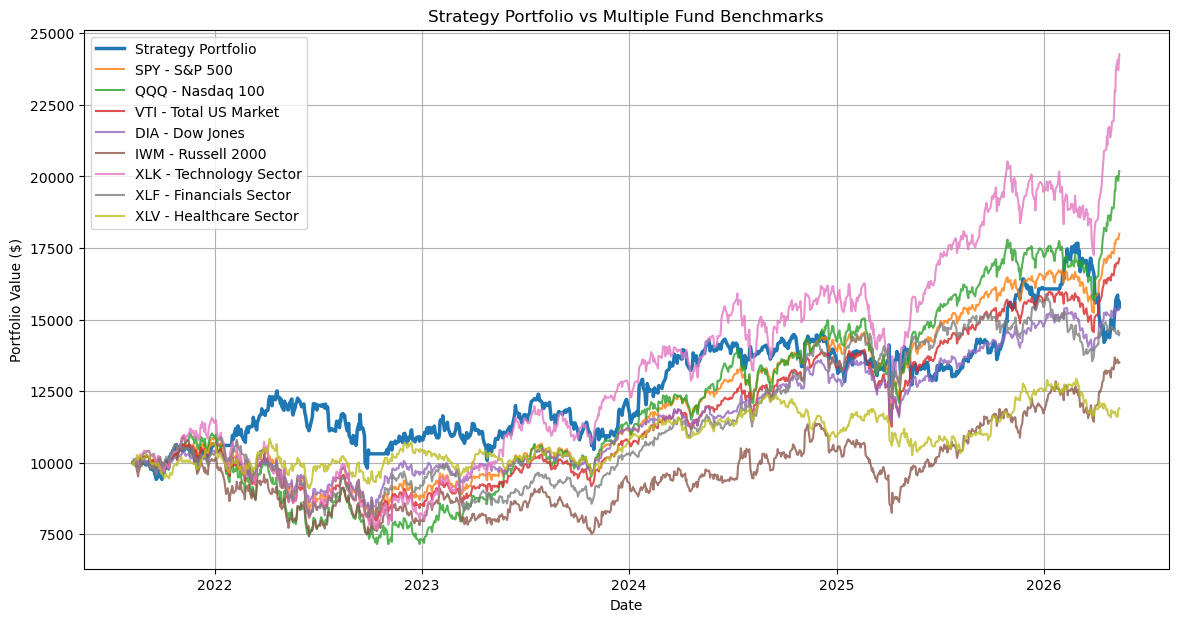

In [53]:
# =========================
# SECTION 7E: PLOT STRATEGY VS MULTIPLE FUNDS
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(
    portfolio_df["Date"],
    portfolio_df["Portfolio_Value"],
    label="Strategy Portfolio",
    linewidth=2.5
)

for ticker, curve in benchmark_curves.items():
    plt.plot(
        curve["Date"],
        curve["Benchmark_Value"],
        label=f"{ticker} - {BENCHMARK_TICKERS.get(ticker, ticker)}",
        alpha=0.8
    )

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Strategy Portfolio vs Multiple Fund Benchmarks")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# %%
# =========================
# SECTION 8A: NEWS / GPT MODULE CONFIG
# =========================

NEWS_CANDIDATE_COUNT = 20
NEWS_SCORES_FILE = "news_scores.csv"

# Keep GPT/news as a helper, not the main decision-maker
NEWS_WEIGHT = 0.30
TECHNICAL_WEIGHT = 0.70

MAX_RISK_SCORE_ALLOWED = 0.75
MIN_CATALYST_SCORE_FOR_WATCHLIST = 0.60

# Safety switch: keep False until you have checked news_records
RUN_GPT_API = True

# Use a cheaper API model where possible.
# If this model name is unavailable on your account, replace it with one available in your OpenAI dashboard.
GPT_NEWS_MODEL = "gpt-5.4-mini"

In [55]:
# %%
# =========================
# SECTION 8B: SELECT BOTTOM 20 NEWS CANDIDATES
# =========================

def select_bottom_news_candidates(ranked_df, bottom_n=20):
    """
    Selects bottom-ranked stocks for GPT news/catalyst analysis.

    These are not automatic buys.
    The goal is to check whether weak stocks have recovery/catalyst potential.
    """

    candidates = ranked_df.tail(bottom_n).copy()
    candidates = candidates.reset_index(drop=True)

    return candidates


bottom_20_news_candidates = select_bottom_news_candidates(
    ranked_df=ranked_df,
    bottom_n=NEWS_CANDIDATE_COUNT
)

bottom_20_news_candidates[
    [
        "Ticker",
        "Sector",
        "Close",
        "Momentum_20D",
        "Volume_Ratio",
        "Volatility_20D",
        "Technical_Score",
        "Signal",
        "Risk_Notes"
    ]
]

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,Technical_Score,Signal,Risk_Notes
0,AMGN,Healthcare,336.625214,-0.036535,0.122693,0.016413,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
1,MMM,Industrials,144.919998,-0.037396,0.080664,0.016725,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
2,DUK,Utilities,123.760002,-0.037861,0.116304,0.010458,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
3,GILD,Healthcare,133.014999,-0.039950,0.095519,0.014105,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
4,BMY,Healthcare,56.549999,-0.040875,0.111186,0.017955,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
5,HON,Industrials,216.759995,-0.055018,0.143231,0.017119,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
6,PEP,Consumer Staples,149.610001,-0.055373,0.137513,0.013054,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
7,T,Communication Services,24.760000,-0.062121,0.203604,0.013641,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
8,NKE,Consumer Discretionary,42.345001,-0.073414,0.257744,0.014147,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
9,LOW,Consumer Discretionary,221.850006,-0.080460,0.134264,0.019914,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"


In [56]:
# %%
# =========================
# SECTION 8C: NEWS HEADLINE INPUT
# =========================

"""
For the first version, you can manually add headlines here.

Later, this can be replaced with:
- a news API
- RSS feed
- yfinance news
- another public news source

Keep headlines short to reduce token cost.
"""

MANUAL_HEADLINES = {
    # Example format:
    # "IBM": [
    #     "IBM announces new enterprise AI partnership...",
    #     "Analysts discuss IBM cloud growth outlook..."
    # ],
}


def get_recent_headlines_for_ticker(ticker):
    """
    Returns recent public headlines/snippets for a ticker.

    First version:
    - Uses MANUAL_HEADLINES dictionary.
    - If no headlines exist, returns an empty list.
    """

    return MANUAL_HEADLINES.get(ticker, [])

In [57]:
# %%
# =========================
# SECTION 8D: BUILD GPT INPUT RECORDS
# =========================

def build_gpt_news_input(candidates_df):
    """
    Converts candidate rows into compact records for GPT scoring.
    """

    records = []

    for _, row in candidates_df.iterrows():
        ticker = row["Ticker"]

        record = {
            "ticker": ticker,
            "sector": row.get("Sector", "Unknown"),
            "technical_score": int(row["Technical_Score"]),
            "momentum_20d": float(row["Momentum_20D"]),
            "volume_ratio": float(row["Volume_Ratio"]),
            "volatility_20d": float(row["Volatility_20D"]),
            "signal": row.get("Signal", "Unknown"),
            "risk_notes": row.get("Risk_Notes", ""),
            "recent_headlines": get_recent_headlines_for_ticker(ticker)[:5]
        }

        records.append(record)

    return records


news_records = build_gpt_news_input(bottom_20_news_candidates)

news_records[:3]

[{'ticker': 'AMGN',
  'sector': 'Healthcare',
  'technical_score': 2,
  'momentum_20d': -0.036534533015303294,
  'volume_ratio': 0.12269304783436491,
  'volatility_20d': 0.016412509891143515,
  'signal': 'SELL / AVOID',
  'risk_notes': 'Weak volume, Negative momentum, Downtrend',
  'recent_headlines': []},
 {'ticker': 'MMM',
  'sector': 'Industrials',
  'technical_score': 2,
  'momentum_20d': -0.03739624555754373,
  'volume_ratio': 0.08066441494667011,
  'volatility_20d': 0.0167246742979171,
  'signal': 'SELL / AVOID',
  'risk_notes': 'Weak volume, Negative momentum, Downtrend',
  'recent_headlines': []},
 {'ticker': 'DUK',
  'sector': 'Utilities',
  'technical_score': 2,
  'momentum_20d': -0.03786055011829326,
  'volume_ratio': 0.11630357374267335,
  'volatility_20d': 0.010458221388907694,
  'signal': 'SELL / AVOID',
  'risk_notes': 'Weak volume, Negative momentum, Downtrend',
  'recent_headlines': []}]

In [58]:
# %%
# =========================
# SECTION 8E: GPT STOCK ASSESSMENT RUBRIC
# =========================

GPT_STOCK_NEWS_RUBRIC = """
You are scoring stocks for a trading bot.

Rules:
- Do not recommend direct trades.
- Only use the provided metrics and headlines.
- If headlines are missing or weak, use low confidence.
- For technically weak bottom-ranked stocks, positive news should create a watchlist flag, not an automatic buy.
- Be conservative with turnaround claims.
- You may suggest replacement tickers if a company looks weak and better public alternatives exist.
- Replacement suggestions are ideas only. The trading bot must still check technical indicators before buying.

Assess each company using:
1. Public sentiment
2. Competitive position
3. Uniqueness / moat
4. Marketing / narrative strength
5. Positive developments
6. Negative developments
7. Catalyst potential
8. Overall watchlist/replacement potential

Scoring:
- public_sentiment_score: -1 to +1
- competitive_position_score: -1 to +1
- moat_score: 0 to 1
- marketing_narrative_score: 0 to 1
- positive_development_score: 0 to 1
- risk_score: 0 to 1
- catalyst_score: 0 to 1
- overall_news_score: -1 to +1
- confidence: 0 to 1

Decision labels:
- ignore
- watchlist
- replacement_candidate
- exclude

Return JSON only in this exact shape:

{
  "scores": [
    {
      "ticker": "AAPL",
      "public_sentiment_score": 0.0,
      "competitive_position_score": 0.0,
      "moat_score": 0.0,
      "marketing_narrative_score": 0.0,
      "positive_development_score": 0.0,
      "risk_score": 0.0,
      "catalyst_score": 0.0,
      "overall_news_score": 0.0,
      "confidence": 0.0,
      "decision_label": "ignore",
      "replacement_suggestions": ["MSFT", "GOOGL"],
      "reason": "Short reason under 25 words."
    }
  ]
}
"""

In [59]:
# %%
# =========================
# SECTION 8F: GPT API NEWS SCORER
# =========================

import os
import json
from openai import OpenAI

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))


NEWS_RESPONSE_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "scores": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "properties": {
                    "ticker": {"type": "string"},
                    "public_sentiment_score": {"type": "number"},
                    "competitive_position_score": {"type": "number"},
                    "moat_score": {"type": "number"},
                    "marketing_narrative_score": {"type": "number"},
                    "positive_development_score": {"type": "number"},
                    "risk_score": {"type": "number"},
                    "catalyst_score": {"type": "number"},
                    "overall_news_score": {"type": "number"},
                    "confidence": {"type": "number"},
                    "decision_label": {
                        "type": "string",
                        "enum": ["ignore", "watchlist", "replacement_candidate", "exclude"]
                    },
                    "replacement_suggestions": {
                        "type": "array",
                        "items": {"type": "string"}
                    },
                    "reason": {"type": "string"}
                },
                "required": [
                    "ticker",
                    "public_sentiment_score",
                    "competitive_position_score",
                    "moat_score",
                    "marketing_narrative_score",
                    "positive_development_score",
                    "risk_score",
                    "catalyst_score",
                    "overall_news_score",
                    "confidence",
                    "decision_label",
                    "replacement_suggestions",
                    "reason"
                ]
            }
        }
    },
    "required": ["scores"]
}


def score_news_with_gpt(news_records):
    """
    Sends candidate stock records to GPT and receives structured news scores.
    """

    prompt = {
        "task": "Score these bottom-ranked stocks for news/catalyst/replacement potential.",
        "rubric": GPT_STOCK_NEWS_RUBRIC,
        "stocks": news_records
    }

    response = client.responses.create(
        model=GPT_NEWS_MODEL,
        input=[
            {
                "role": "system",
                "content": (
                    "You are a conservative stock-news scoring assistant. "
                    "Return valid structured JSON only. Do not recommend direct trades."
                )
            },
            {
                "role": "user",
                "content": json.dumps(prompt)
            }
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "stock_news_scores",
                "schema": NEWS_RESPONSE_SCHEMA,
                "strict": True
            }
        }
    )

    result = json.loads(response.output_text)

    return result

In [60]:
# %%
# =========================
# SECTION 8G: SAVE GPT NEWS SCORES TO CSV
# =========================

from datetime import date

def append_news_scores_to_csv(gpt_result, filename=NEWS_SCORES_FILE):
    """
    Appends GPT scores to one growing CSV file.
    """

    today_str = date.today().isoformat()
    scores = gpt_result.get("scores", [])

    rows = []

    for item in scores:
        rows.append({
            "date": today_str,
            "ticker": item.get("ticker"),
            "public_sentiment_score": item.get("public_sentiment_score"),
            "competitive_position_score": item.get("competitive_position_score"),
            "moat_score": item.get("moat_score"),
            "marketing_narrative_score": item.get("marketing_narrative_score"),
            "positive_development_score": item.get("positive_development_score"),
            "risk_score": item.get("risk_score"),
            "catalyst_score": item.get("catalyst_score"),
            "overall_news_score": item.get("overall_news_score"),
            "confidence": item.get("confidence"),
            "decision_label": item.get("decision_label"),
            "replacement_suggestions": ", ".join(item.get("replacement_suggestions", [])),
            "reason": item.get("reason")
        })

    new_scores_df = pd.DataFrame(rows)

    if os.path.exists(filename):
        old_scores_df = pd.read_csv(filename)
        combined_df = pd.concat([old_scores_df, new_scores_df], ignore_index=True)
    else:
        combined_df = new_scores_df

    combined_df.to_csv(filename, index=False)

    return combined_df


def load_latest_news_scores(filename=NEWS_SCORES_FILE):
    """
    Loads the latest GPT score for each ticker.
    """

    if not os.path.exists(filename):
        return pd.DataFrame()

    news_df = pd.read_csv(filename)
    news_df["date"] = pd.to_datetime(news_df["date"])

    latest_scores = (
        news_df.sort_values("date")
        .groupby("ticker")
        .tail(1)
        .reset_index(drop=True)
    )

    return latest_scores

In [61]:
# %%
# =========================
# SECTION 8H: RUN DAILY GPT NEWS SCORING
# =========================

if RUN_GPT_API:
    # Start with a small test first to control cost
    test_records = news_records[:3]

    gpt_result = score_news_with_gpt(test_records)

    news_scores_df = append_news_scores_to_csv(
        gpt_result=gpt_result,
        filename=NEWS_SCORES_FILE
    )

    display(news_scores_df.tail(10))

else:
    print("RUN_GPT_API is False.")
    print("Check news_records first before spending API money.")
    print("Preview of records that would be sent to GPT:")
    display(pd.DataFrame(news_records).head(5))

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
# %%
# =========================
# SECTION 8I: EXTRACT GPT REPLACEMENT SUGGESTIONS
# =========================

def extract_replacement_suggestions(news_scores_df):
    """
    Extracts replacement tickers suggested by GPT.
    """

    suggestions = set()

    if news_scores_df.empty:
        return []

    latest_scores = load_latest_news_scores()

    for _, row in latest_scores.iterrows():
        raw_suggestions = row.get("replacement_suggestions", "")

        if pd.isna(raw_suggestions) or raw_suggestions == "":
            continue

        tickers = [
            ticker.strip().upper()
            for ticker in raw_suggestions.split(",")
            if ticker.strip() != ""
        ]

        for ticker in tickers:
            suggestions.add(ticker)

    return sorted(list(suggestions))


latest_news_scores = load_latest_news_scores()

replacement_watchlist = extract_replacement_suggestions(latest_news_scores)

replacement_watchlist

[]

In [ ]:
# %%
# =========================
# SECTION 8J: RE-RUN TECHNICAL SCAN WITH WATCHLIST
# =========================

def run_current_technical_scan(tickers):
    """
    Downloads latest data, calculates indicators, evaluates strategy,
    and returns a ranked dataframe.

    This is for live/paper testing, not backtesting.
    """

    scan_stock_data = collect_universe_data(tickers)

    scan_indicator_data = {}

    for ticker, data in scan_stock_data.items():
        scan_indicator_data[ticker] = calculate_indicators(data)

    scan_results = []

    for ticker, data in scan_indicator_data.items():
        try:
            result = evaluate_strategy(ticker, data)
            scan_results.append(result)

        except Exception as e:
            print(f"Could not evaluate strategy for {ticker}: {e}")

    scan_df = pd.DataFrame(scan_results)

    if scan_df.empty:
        return scan_df

    scan_df["Technical_Score"] = scan_df.apply(calculate_technical_score, axis=1)
    scan_df["Signal"] = scan_df.apply(generate_signal, axis=1)
    scan_df["Risk_Notes"] = scan_df.apply(assess_stock_risk, axis=1)

    scan_ranked_df = scan_df.sort_values(
        by=["Technical_Score", "Momentum_20D"],
        ascending=[False, False]
    ).reset_index(drop=True)

    scan_ranked_df["Technical_Rank"] = scan_ranked_df.index + 1

    return scan_ranked_df


RUN_EXPANDED_SCAN = False

if RUN_EXPANDED_SCAN:
    ACTIVE_TICKERS = sorted(list(set(TICKERS + replacement_watchlist)))

    expanded_ranked_df = run_current_technical_scan(ACTIVE_TICKERS)

    display(expanded_ranked_df.head(20))
else:
    print("RUN_EXPANDED_SCAN is False.")
    print("Replacement watchlist preview:")
    print(replacement_watchlist)

RUN_EXPANDED_SCAN is False.
Replacement watchlist preview:
[]
